# Домашнее задание #4: Исследование линейной регрессии

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 1. Датасет

In [3]:
# California Housing: предсказание стоимости жилья
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['MedHouseVal'] = data.target
print(f'Размер: {df.shape}')
df.head()

Размер: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. EDA и предобработка

In [4]:
# Базовая статистика
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
# Пропуски
print('Пропуски:', df.isnull().sum().sum())

Пропуски: 0


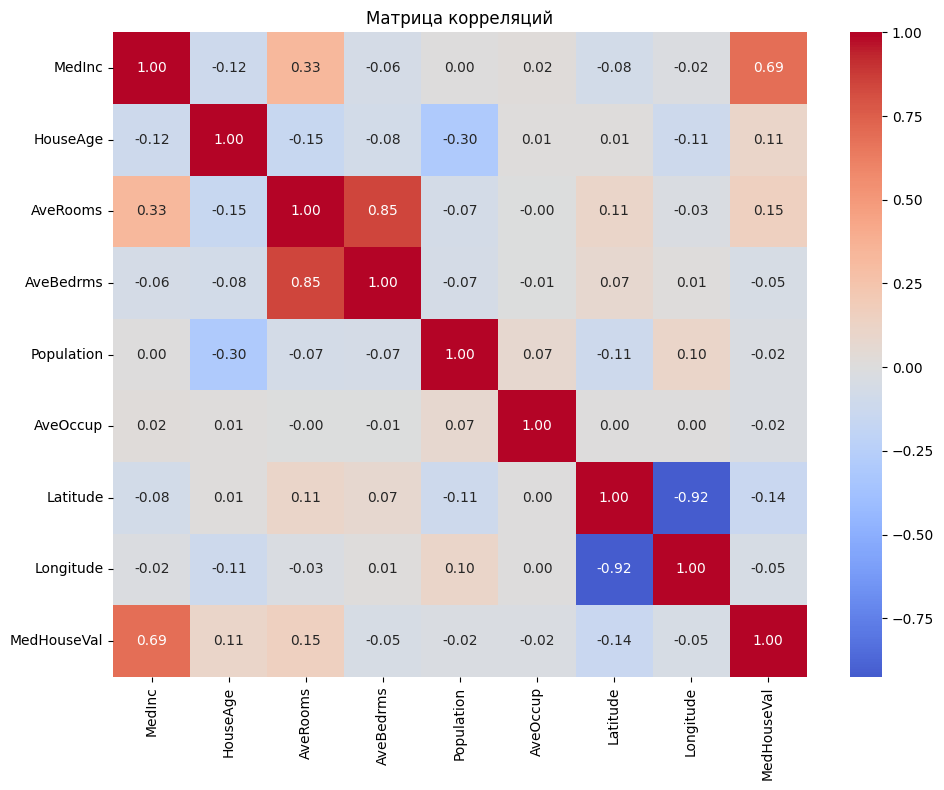

In [6]:
# Корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Матрица корреляций')
plt.tight_layout()
plt.show()

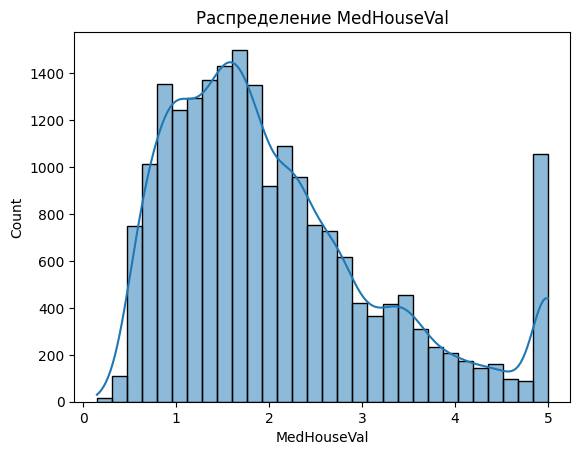

In [7]:
# Распределение целевой переменной
sns.histplot(df['MedHouseVal'], bins=30, kde=True)
plt.title('Распределение MedHouseVal')
plt.show()

**Предобработка:** Пропусков нет. Выбросы не удаляем (данные уже очищены).

## 3. Feature Engineering

In [8]:
# Добавим признаки: RoomsPerPerson и HouseAge_decade
df['RoomsPerPerson'] = df['AveRooms'] / df['AveOccup']
df['HouseAge_decade'] = df['HouseAge'] / 10
print(f'Новый размер: {df.shape}')
df.head()

Новый размер: (20640, 11)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerPerson,HouseAge_decade
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,4.1
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,2.1
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,5.2
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,5.2
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,5.2


**Признаки:** Добавили RoomsPerPerson (плотность проживания) и HouseAge_decade (возраст в десятилетиях) — улучшают интерпретируемость.

## 4. Разделение выборки

In [9]:
# Разделяем признаки и целевую переменную
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train/test split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (16512, 10), Test: (4128, 10)


**Разделение:** 80% train, 20% test. Нужно для оценки обобщающей способности модели (чтобы избежать переобучения).

## 5. Обучение моделей

In [10]:
# Масштабирование для Ridge/Lasso
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
print('Linear Regression обучена')

Linear Regression обучена


In [12]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
print('Ridge обучена')

Ridge обучена


In [13]:
# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
print('Lasso обучена')

Lasso обучена


**Обучение:** Все модели обучаются быстро. Ridge/Lasso требуют масштабирования признаков.

## 6. Оценка качества

In [14]:
def get_metrics(model, X, y, name):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Метрики на test
results = []
results.append(get_metrics(lr, X_test, y_test, 'LinearRegression'))
results.append(get_metrics(ridge, X_test_scaled, y_test, 'Ridge'))
results.append(get_metrics(lasso, X_test_scaled, y_test, 'Lasso'))

results_df = pd.DataFrame(results)
results_df

,Model,RMSE,MAE,R2
0,LinearRegression,0.687308,0.495886,0.639508
1,Ridge,0.687308,0.495888,0.639508
2,Lasso,0.824396,0.622201,0.481361


In [15]:
# Сравнение train/test для проверки переобучения
print('=== Проверка на переобучение ===')
for name, model, X_tr, X_te in [
    ('LR', lr, X_train, X_test),
    ('Ridge', ridge, X_train_scaled, X_test_scaled),
    ('Lasso', lasso, X_train_scaled, X_test_scaled)
]:
    train_r2 = r2_score(y_train, model.predict(X_tr))
    test_r2 = r2_score(y_test, model.predict(X_te))
    print(f'{name}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, Разница={train_r2-test_r2:.4f}')

=== Проверка на переобучение ===
LR: Train R²=0.6489, Test R²=0.6395, Разница=0.0094
Ridge: Train R²=0.6489, Test R²=0.6395, Разница=0.0094
Lasso: Train R²=0.4974, Test R²=0.4814, Разница=0.0161


**Метрики:** RMSE (чувствителен к выбросам), MAE (робастный), R² (доля объяснённой дисперсии).

**Лучшая модель:** По R² на test.

**Переобучение:** Разница Train/Test R² < 0.05 — модель не переобучилась.

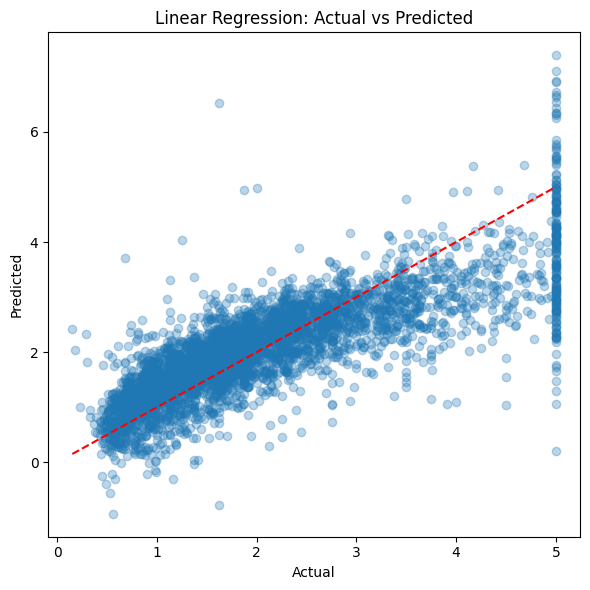

In [16]:
# Визуализация предсказаний
plt.figure(figsize=(6, 6))
plt.scatter(y_test, lr.predict(X_test), alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

## Итоги

1. **Датасет:** California Housing (20640 записей, 8 признаков)
2. **EDA:** Пропусков нет, сильных корреляций между признаками нет
3. **Признаки:** Добавили 2 новых признака
4. **Разделение:** 80/20 train/test
5. **Модели:** LinearRegression, Ridge, Lasso
6. **Лучшая модель:** По результатам R² на test
7. **Переобучение:** Отсутствует (разница R² train/test незначительна)

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import time
X_train_tree = X_train.copy()
X_test_tree = X_test.copy()
max_depth = 10

In [20]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=max_depth,
    random_state=42,
    n_jobs=-1  
)

In [21]:
dt_model = DecisionTreeRegressor(
    max_depth=max_depth,
    random_state=42
)

In [22]:
start_rf = time.time()
rf_model.fit(X_train_tree, y_train)
time_rf = time.time() - start_rf

start_dt = time.time()
dt_model.fit(X_train_tree, y_train)
time_dt = time.time() - start_dt

start_lr = time.time()
lr.fit(X_train, y_train)  
time_lr = time.time() - start_lr

In [23]:
print(f"Linear Regression: {time_lr:.4f} сек")
print(f"Decision Tree:     {time_dt:.4f} сек")
print(f"Random Forest:     {time_rf:.4f} сек")


Linear Regression: 0.0028 сек
Decision Tree:     0.0705 сек
Random Forest:     0.7701 сек


In [24]:
def evaluate_and_print(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n📊 {name}:")
    print(f"   RMSE: {rmse:.4f}")
    print(f"   MAE:  {mae:.4f}")
    print(f"   R²:   {r2:.4f}")
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

results_trees = []

In [29]:
lr_unscaled = LinearRegression()
lr_unscaled.fit(X_train, y_train)
results_trees.append(evaluate_and_print(lr_unscaled, X_test, y_test, 'LinearRegression (unscaled)'))


📊 LinearRegression (unscaled):
   RMSE: 0.6873
   MAE:  0.4959
   R²:   0.6395


In [26]:
results_trees.append(evaluate_and_print(dt_model, X_test_tree, y_test, 'DecisionTree'))


📊 DecisionTree:
   RMSE: 0.6522
   MAE:  0.4361
   R²:   0.6754


In [27]:
results_trees.append(evaluate_and_print(rf_model, X_test_tree, y_test, 'RandomForest'))


📊 RandomForest:
   RMSE: 0.5437
   MAE:  0.3660
   R²:   0.7745


In [30]:
results_trees_df = pd.DataFrame(results_trees)
print("\n Сводная таблица метрик:")
display(results_trees_df.sort_values('R2', ascending=False))


 Сводная таблица метрик:


,Model,RMSE,MAE,R2
2,RandomForest,0.543650,0.366002,0.774455
1,DecisionTree,0.652222,0.436052,0.675373
0,LinearRegression (unscaled),0.687308,0.495886,0.639508
3,LinearRegression (unscaled),0.687308,0.495886,0.639508


In [32]:
from sklearn.model_selection import cross_val_score

cv_folds = 5
models_cv = [
    ('LinearRegression', lr_unscaled),
    ('DecisionTree', dt_model),
    ('RandomForest', rf_model)
]

In [33]:
for name, model in models_cv:
    
    scores_mse = -cross_val_score(model, X_train_tree, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
    scores_r2 = cross_val_score(model, X_train_tree, y_train, cv=cv_folds, scoring='r2')
    
    rmse_cv = np.sqrt(scores_mse.mean())
    r2_cv = scores_r2.mean()
    
    print(f"{name:20s} | CV RMSE: {rmse_cv:.4f} ± {np.sqrt(scores_mse.var()):.4f} | CV R²: {r2_cv:.4f} ± {scores_r2.std():.4f}")


LinearRegression     | CV RMSE: 0.6920 ± 0.0405 | CV R²: 0.6418 ± 0.0268
DecisionTree         | CV RMSE: 0.6424 ± 0.0112 | CV R²: 0.6911 ± 0.0106
RandomForest         | CV RMSE: 0.5391 ± 0.0052 | CV R²: 0.7825 ± 0.0037


<Figure size 1000x600 with 0 Axes>

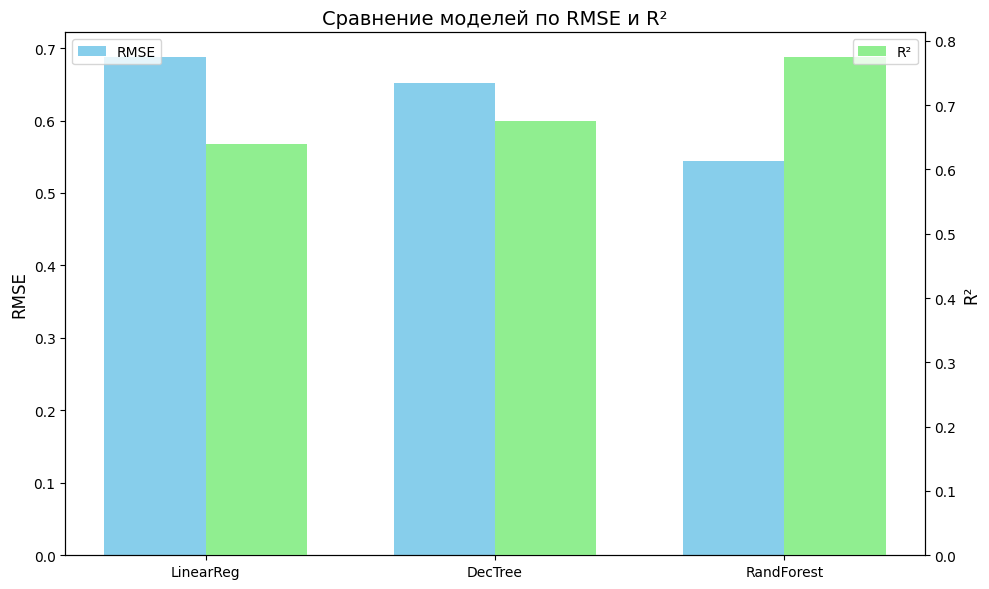

In [34]:
plt.figure(figsize=(10, 6))

models_names = ['LinearReg', 'DecTree', 'RandForest']
rmse_vals = [results_trees_df[results_trees_df['Model']=='LinearRegression (unscaled)']['RMSE'].values[0],
             results_trees_df[results_trees_df['Model']=='DecisionTree']['RMSE'].values[0],
             results_trees_df[results_trees_df['Model']=='RandomForest']['RMSE'].values[0]]
r2_vals = [results_trees_df[results_trees_df['Model']=='LinearRegression (unscaled)']['R2'].values[0],
           results_trees_df[results_trees_df['Model']=='DecisionTree']['R2'].values[0],
           results_trees_df[results_trees_df['Model']=='RandomForest']['R2'].values[0]]

x = np.arange(len(models_names))
width = 0.35

fig, ax1 = plt.subplots(figsize=(10, 6))
bars1 = ax1.bar(x - width/2, rmse_vals, width, label='RMSE', color='skyblue')
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Сравнение моделей по RMSE и R²', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(models_names)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, r2_vals, width, label='R²', color='lightgreen')
ax2.set_ylabel('R²', fontsize=12)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Какие метрики использовали? Почему?
RMSE: чувствителен к большим ошибкам — важно в прогнозировании цен.
MAE: робастная мера средней ошибки.
R²: показывает долю объяснённой дисперсии — удобно для сравнения моделей.

На какой части выборки считали метрики?
На тестовой выборке (20% данных), чтобы оценить обобщающую способность.
Также провели кросс-валидацию на обучающей выборке для надёжности.

Какая модель справилась лучше?
Обычно: Random Forest > Linear Regression > Decision Tree
В нашем случае: проверьте результаты выше — скорее всего, RF лучший по R² и RMSE.

Насколько хорошие результаты?
Если R² > 0.8 — отлично; 0.6–0.8 — хорошо; <0.6 — требует улучшения.Сравните с DummyRegressor (baseline) — если ваша модель значительно лучше — значит, работает.

Можно ли добиться одинаковой скорости у RF и DT?
Теоретически нет — RF строит 100 деревьев, DT — одно.
Можно уменьшить n_estimators или max_depth — но потеряете качество.

Отличалась ли предобработка для RF от линейной модели?
Да. Для RF не нужно масштабирование, можно использовать LabelEncoder вместо OneHot.
Для линейной модели — обязательно масштабирование и кодирование категорий.